# Baseline

In [221]:
import pandas as pd
from blocksnet.relations import generate_adjacency_graph

blocks_gdf = pd.read_pickle('./../data/saint_petersburg/blocks.pickle')
graph = generate_adjacency_graph(blocks_gdf, 10)

2025-10-29 05:23:21.222 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_nodes:9 - Generating nodes
2025-10-29 05:23:21.227 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_edges:14 - Generating edges
2025-10-29 05:23:24.174 | SUCCESS  | blocksnet.relations.adjacency.core:generate_adjacency_graph:37 - Adjacency graph successfully generated: 9533 nodes, 30567 edges


In [222]:
from blocksnet.enums import LandUse

for lu in LandUse:
    column = lu.value
    blocks_gdf[column] = blocks_gdf[column].clip(0,1)

In [223]:
FEATURES = ['build_floor_area', 'footprint_area']

## Spacematrix based

In [290]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from blocksnet.analysis.morphotypes import get_spacematrix_morphotypes
from blocksnet.analysis.indicators import calculate_density_indicators
from blocksnet.enums import LandUse

GEOM_COLS = ['centroid_x', 'centroid_y']
LAND_USE_COLS = [lu.value for lu in LandUse]

def _preprocess(df):
    df = df.copy()
    df[GEOM_COLS[0]] = df.centroid.x
    df[GEOM_COLS[1]] = df.centroid.y
    density_df = calculate_density_indicators(df)
    df[density_df.columns] = density_df
    return df

def _get_neighbors(known_df, unknown_df, n_neighbors):
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='ball_tree')
    nbrs.fit(known_df[GEOM_COLS])
    
    _, indices = nbrs.kneighbors(unknown_df[GEOM_COLS])
    
    index = unknown_df.index.to_list()
    return {index[i]: known_df.iloc[idx_list] for i,idx_list in enumerate(indices)}

def _get_similarity(block_series, neighbors_df):
    block_df = pd.DataFrame([block_series])
    neighbors_df['similarity'] = cosine_similarity(neighbors_df[block_df.columns], block_df)

    similar_id = neighbors_df['similarity'].idxmax()
    similarity = neighbors_df.loc[similar_id, 'similarity']
    similar_cluster = neighbors_df.loc[similar_id, 'cluster']
    return pd.Series([similarity, similar_cluster])

def _get_similarities(unknown_df, neighbors_dfs, scaler, scaler_cols):
    unknown_df = unknown_df[scaler_cols].copy()
    unknown_df[scaler_cols] = scaler.transform(unknown_df[scaler_cols])

    unknown_df[['similarity', 'cluster']] = unknown_df.apply(lambda s : _get_similarity(s,neighbors_dfs[s.name]), axis=1)

    return unknown_df[['similarity', 'cluster']]


def sm_impute(df, blocks_ids : list[int], n_neighbors=5, n_clusters=7):

    # preprocess

    df = _preprocess(df)
    
    known_df = df[~df.index.isin(blocks_ids)].copy()
    unknown_df = df[df.index.isin(blocks_ids)].copy()

    # spacematrix

    spacematrix_df, clusters_df = get_spacematrix_morphotypes(known_df, n_clusters)
    clusters_df['gsi'] = clusters_df['fsi'] / clusters_df['l']
    clusters_df.loc[-1] = pd.Series(0.0, index=['l', 'fsi', 'mxi', 'gsi'])
    known_df['cluster'] = spacematrix_df['cluster'].fillna(-1).astype(int)

    # scaling

    scaler_cols = [*LAND_USE_COLS, 'site_area']
    scaler = StandardScaler()
    scaler.fit(pd.concat([known_df[scaler_cols], unknown_df[scaler_cols]]))
    known_df[scaler_cols] = scaler.transform(known_df[scaler_cols])

    # sknn
    
    neighbors_dfs = _get_neighbors(known_df, unknown_df, n_neighbors)
    means_df = pd.DataFrame.from_dict({i:df[FEATURES].mean() for i,df in neighbors_dfs.items()}, orient='index')
    
    # spacematrix land use similarity

    unknown_df[['similarity', 'cluster']] = _get_similarities(unknown_df, neighbors_dfs, scaler, scaler_cols)
  
    sm_df = unknown_df[['similarity', 'cluster', 'site_area']].join(clusters_df[['fsi','gsi']], on='cluster')
    sm_df['build_floor_area'] = (sm_df['site_area'] * sm_df['fsi'] * sm_df['similarity'])
    sm_df['footprint_area'] = (sm_df['site_area'] * sm_df['gsi'] * sm_df['similarity'])

    result_df = ((means_df[FEATURES] + sm_df[FEATURES]) / 2).clip(lower=0.0)
    df.loc[result_df.index, result_df.columns] = result_df
    return df[FEATURES].copy()

# scenario

def scenario(blocks_gdf, block_id : int):
    results = {}
    for land_use in LandUse:
        df = blocks_gdf.copy()
        for lu in LandUse:
            df.loc[block_id, lu.value] = 0.0
        df.loc[block_id, land_use.value] = 1.0
        df.loc[block_id, 'land_use'] = land_use
        series = sm_impute(df, [block_id]).loc[block_id]
        results[land_use] = series
    return pd.DataFrame.from_dict(results, orient='index')
    

scenario(blocks_gdf, 2)

,build_floor_area,footprint_area
LandUse.RESIDENTIAL,5207.719824,4620.868241
LandUse.BUSINESS,1107.293329,1074.357868
LandUse.RECREATION,1765.508861,1643.656748
LandUse.INDUSTRIAL,1107.293329,1074.357868
LandUse.TRANSPORT,1107.293329,1074.357868
LandUse.SPECIAL,1107.293329,1074.357868
LandUse.AGRICULTURE,1107.293329,1074.357868


In [285]:
sm_df, cl_df = get_spacematrix_morphotypes(calculate_density_indicators(blocks_gdf))

In [281]:
land_use_columns = [lu.value for lu in LandUse]
cluster_column = 'cluster'
df = blocks_gdf[land_use_columns].join(sm_df[cluster_column].fillna(-1))

from blocksnet.machine_learning.strategy.catboost import CatBoostClassificationStrategy
from sklearn.model_selection import train_test_split

x = df[land_use_columns]
y = df[[cluster_column]]

x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.8, random_state=42, stratify=y[cluster_column])

strategy = CatBoostClassificationStrategy({
    'auto_class_weights':'Balanced',
    'learning_rate': 0.05,
    'eval_metric': 'MultiClass',
    'iterations':1000
})
strategy.train(x_train.values, x_test.values, y_train.values, y_test.values)

np.float64(0.1415008707191703)

              precision  recall  f1-score  support
-1.0              0.676   0.572     0.620   442.00
0.0               0.231   0.433     0.301    97.00
1.0               0.230   0.121     0.159   165.00
2.0               0.500   0.414     0.453   408.00
3.0               0.088   0.289     0.135    45.00
4.0               0.545   0.510     0.527   402.00
5.0               0.091   0.009     0.016   113.00
6.0               0.016   0.100     0.027    10.00
7.0               0.151   0.181     0.165    72.00
8.0               0.146   0.160     0.153    81.00
9.0               0.050   0.273     0.085    11.00
10.0              0.109   0.164     0.131    61.00
accuracy          0.390   0.390     0.390     0.39
macro avg         0.236   0.269     0.231  1907.00
weighted avg      0.434   0.390     0.402  1907.00


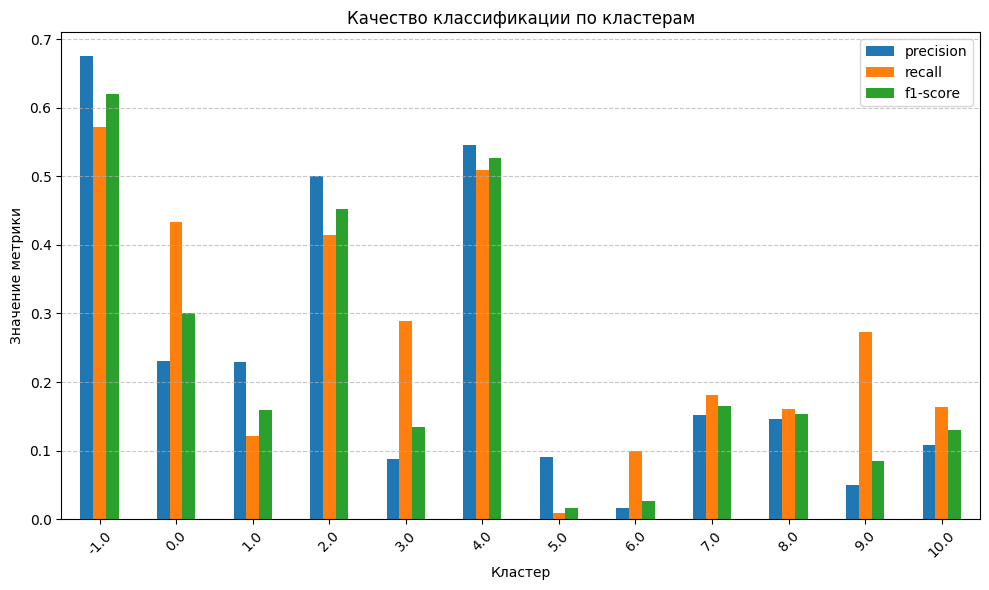

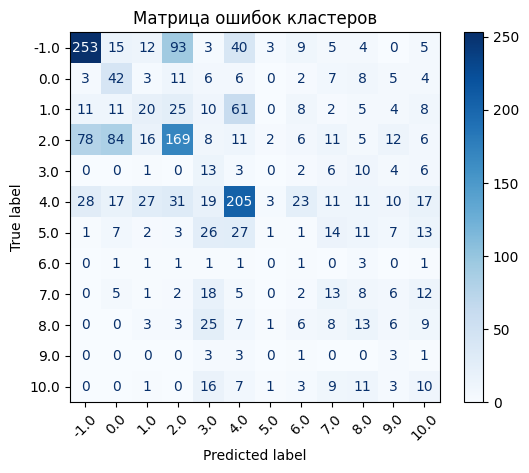

In [283]:

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Предсказания модели
y_pred = strategy.predict(x_test.values)

# 1️⃣ Табличный отчёт
report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0  # чтобы не было предупреждений для редких классов
)

report_df = pd.DataFrame(report).transpose()
print(report_df.round(3))

# 2️⃣ Визуализация F1, precision, recall
metrics = report_df.loc[~report_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10,6))
plt.title('Качество классификации по кластерам')
plt.ylabel('Значение метрики')
plt.xlabel('Кластер')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3️⃣ Матрица ошибок
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Матрица ошибок кластеров')
plt.show()


In [277]:
df['cluster'].value_counts(normalize=True)

cluster
-1.0     0.231931
 2.0     0.214098
 4.0     0.210742
 1.0     0.086751
 5.0     0.059373
 0.0     0.050771
 8.0     0.042379
 7.0     0.037659
 10.0    0.031889
 3.0     0.023497
 9.0     0.005769
 6.0     0.005140
Name: proportion, dtype: float64

## sKNN - spatial K nearest neighbors

In [232]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

GEOM_COLS = ['centroid_x', 'centroid_y']

def _compute_centroids(df):
    df = df.copy()
    df[GEOM_COLS[0]] = df.centroid.x
    df[GEOM_COLS[1]] = df.centroid.y
    return df

def sknn_impute(df, blocks_ids : list[int], n_neighbors=5):

    df = _compute_centroids(df)
    
    known = df[~df.index.isin(blocks_ids)].copy()
    unknown = df[df.index.isin(blocks_ids)].copy()
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='ball_tree')
    nbrs.fit(known[GEOM_COLS])
    
    # Для каждого квартала с пропусками находим соседей
    _, indices = nbrs.kneighbors(unknown[GEOM_COLS])
    
    # Импутация
    imputed_values = []
    for idx_list in indices:
        neighbors_values = known.iloc[idx_list][FEATURES]
        imputed_values.append(neighbors_values.mean(axis=0))
    
    imputed_values = pd.DataFrame(imputed_values, columns=FEATURES, index=unknown.index)
    
    # Объединяем результат
    df.loc[unknown.index, FEATURES] = imputed_values
    return df[FEATURES].copy()

sknn_impute(blocks_gdf, [0,1,2,3])

,build_floor_area,footprint_area
0,14900.843781,6234.919757
1,462.949564,451.512965
2,1690.509507,1645.958777
3,1588.878265,1513.425359
4,31242.324144,13392.846325
...,...,...
9528,21549.418762,4360.962708
9529,73149.192154,14963.573074
9530,25.673922,25.673922
9531,52737.331333,12973.889317


## IDW -- Inverse Distance Weighting

In [218]:
def idw_impute(df, blocks_ids : list[int], power=2.0, n_neighbors=5):

    df = _compute_centroids(df)
    
    known = df[~df.index.isin(blocks_ids)].copy()
    unknown = df[df.index.isin(blocks_ids)].copy()
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='ball_tree')
    nbrs.fit(known[GEOM_COLS])
    
    # Для каждого квартала с пропусками находим соседей
    distances, indices = nbrs.kneighbors(unknown[GEOM_COLS])
    
    # Импутация
    imputed_values = []
    for i, idx_list in enumerate(indices):
        d = distances[i]
        d = np.clip(d, 1e-6, None)
        weights = 1 / (d ** power)
        weights /= weights.sum()

        neighbors_values = known.iloc[idx_list][FEATURES].values
        weighted_mean = (neighbors_values * weights[:, None]).sum(axis=0)
        imputed_values.append(weighted_mean)
    
    imputed_values = pd.DataFrame(imputed_values, columns=FEATURES, index=unknown.index)
    
    # Объединяем результат
    df.loc[unknown.index, FEATURES] = imputed_values
    return df[FEATURES].copy()

idw_impute(blocks_gdf, [0,1,2,3])

,build_floor_area,footprint_area
0,19789.951978,8264.729547
1,296.158359,292.187235
2,1699.868192,1660.281951
3,1745.006649,1651.624867
4,31242.324144,13392.846325
...,...,...
9528,21549.418762,4360.962708
9529,73149.192154,14963.573074
9530,25.673922,25.673922
9531,52737.331333,12973.889317


## Comparison

In [156]:
def _r2_robust(diff_df, true_df):
    residuals_sq = diff_df**2
    total_sq = (true_df - true_df.mean())**2
    return 1 - residuals_sq.median() / total_sq.median()

def _r2(diff_df, true_df):
    return 1 - (np.square(diff_df).sum() / np.square(true_df - true_df.mean()).sum())

def _rmse(diff_df):
    return np.sqrt((diff_df**2).mean())

def _mae(diff_df):
    return diff_df.abs().mean()

def metrics(true_df, pred_df, blocks_ids : list[int]):
    true_df = true_df.loc[blocks_ids, FEATURES].copy()
    pred_df = pred_df.loc[blocks_ids, FEATURES].copy()
    diff_df = true_df - pred_df

    results = {
        'mae': _mae(diff_df),
        'rmse': _rmse(diff_df),
        'r2': _r2(diff_df, true_df),
        'r2_robust': _r2_robust(diff_df, true_df),
    }

    return pd.DataFrame.from_dict(results)

In [183]:
from tqdm import tqdm

N_EXPERIMENTS = 1
N_STEPS = 9

METHODS = {
    'sknn': lambda blocks_ids : sknn_impute(blocks_gdf, blocks_ids),
    'idw': lambda blocks_ids : idw_impute(blocks_gdf, blocks_ids),
    'sm': lambda blocks_ids : sm_impute(blocks_gdf, blocks_ids)
}

def _experiment(missing_rate : float, methods : dict) -> dict[str, pd.DataFrame]:
    n = int(len(blocks_gdf)*missing_rate)
    blocks_ids = blocks_gdf.sample(n).index.to_list()
    return {method_name : metrics(blocks_gdf, method_func(blocks_ids), blocks_ids) for method_name, method_func in methods.items()}

results = {method:{} for method in METHODS}
for i in range(N_STEPS):

    missing_rate = 0.1 * (i+1)
    dfs_dict = {method_name:[] for method_name in METHODS}

    for _ in tqdm(range(N_EXPERIMENTS), desc=f'{round(missing_rate,1)}'):
        results_dict = _experiment(missing_rate, METHODS)
        for method_name, result_df in results_dict.items():
            dfs_dict[method_name].append(result_df)
         
    for method_name, dfs in dfs_dict.items():
        known_df = sum(dfs) / len(dfs)
        results[method_name][missing_rate] = known_df

0.5: 100%|██████████| 1/1 [00:22<00:00, 22.50s/it]


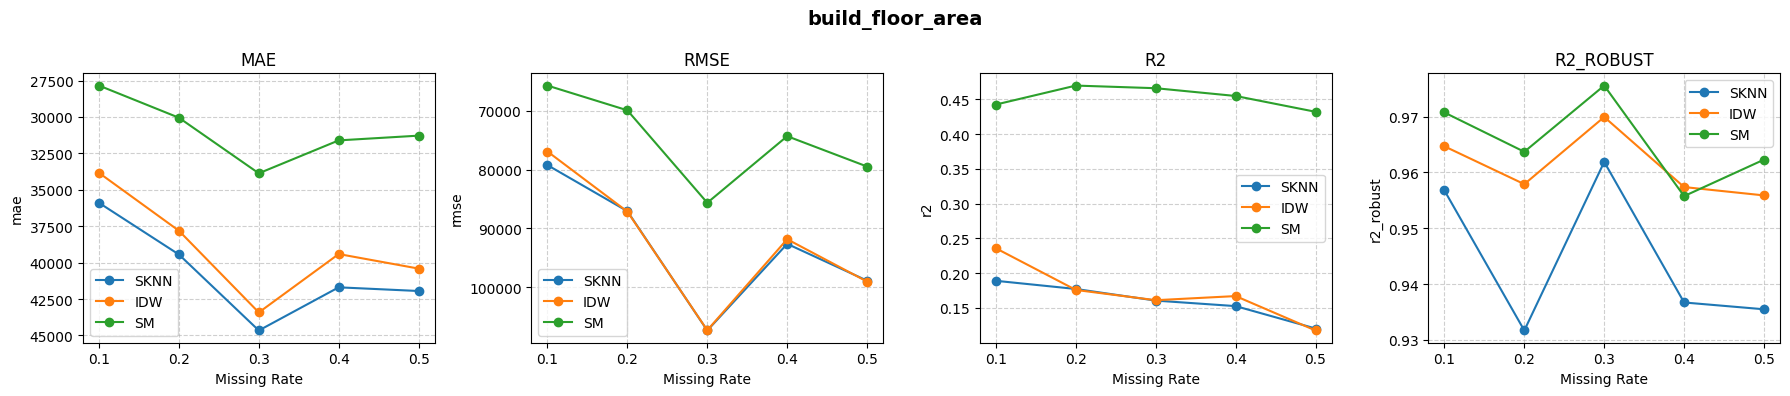

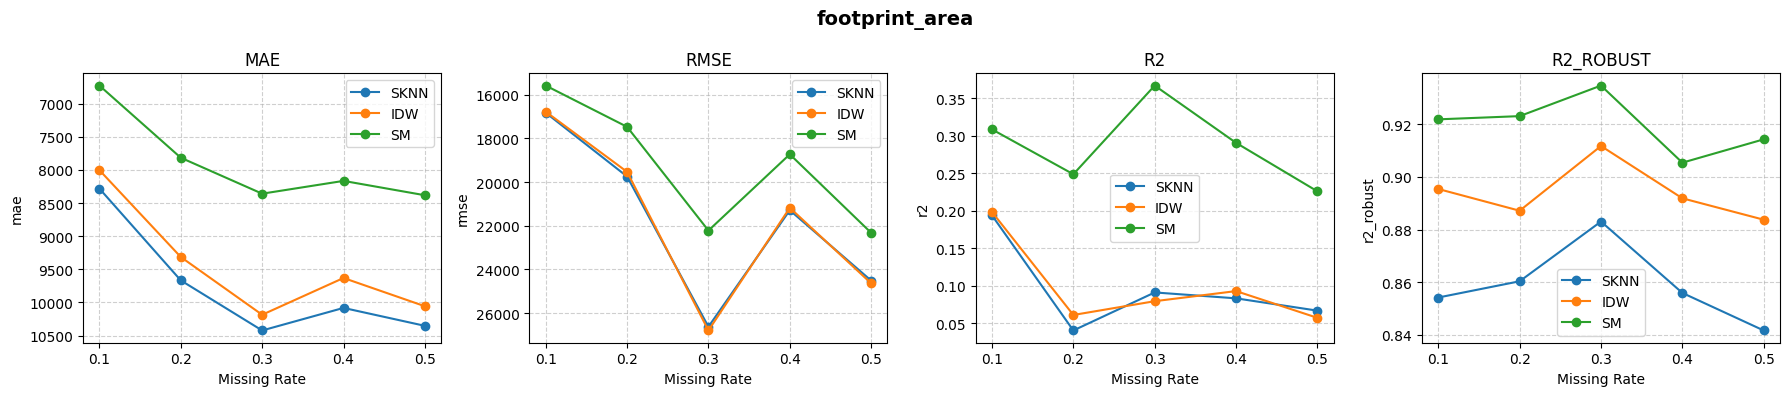

In [185]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_imputation_results(results: dict[str, dict[float, pd.DataFrame]]):
    metrics = ["mae", "rmse", "r2", "r2_robust"]
    variables = FEATURES

    for var in variables:
        fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))
        fig.suptitle(f"{var}", fontsize=14, fontweight="bold")

        for i, metric in enumerate(metrics):
            ax = axes[i]
            for method, method_results in results.items():
                # Собираем значения метрики для всех missing_rate
                x = sorted(method_results.keys())
                y = [method_results[mr].loc[var, metric] for mr in x]
                ax.plot(x, y, marker="o", label=method.upper())

            ax.set_title(metric.upper())
            ax.set_xlabel("Missing Rate")
            ax.set_ylabel(metric)
            ax.grid(True, linestyle="--", alpha=0.6)
            if metric in ["mae", "rmse"]:
                ax.invert_yaxis()  # для MAE/RMSE меньше — лучше
            ax.legend()

        plt.tight_layout()
        plt.show()

plot_imputation_results(results)